# __Numpy Introduction__

In [1]:
import numpy as np

In [2]:
# Python list with temperature values
cvalues = [20.1, 20.8, 21.9, 22.5, 22.7, 22.3, 21.8, 21.2, 20.9, 20.1]

In [3]:
# Converting to a Numpy Array
C = np.array(cvalues)
print(C)

[20.1 20.8 21.9 22.5 22.7 22.3 21.8 21.2 20.9 20.1]


In [4]:
# Convert the elements to the US measure with formula
# US temperature = 9 / 5 * 32 temperature
print(C * 9 / 5 + 32)

[68.18 69.44 71.42 72.5  72.86 72.14 71.24 70.16 69.62 68.18]


In [5]:
# The original array is not changed
print(C)

[20.1 20.8 21.9 22.5 22.7 22.3 21.8 21.2 20.9 20.1]


In [6]:
# DOING THE SAME WITH PLAIN PYTHON
fvalues = [ x*9/5 + 32 for x in cvalues]
print(fvalues)

[68.18, 69.44, 71.42, 72.5, 72.86, 72.14, 71.24000000000001, 70.16, 69.62, 68.18]


In [7]:
# Type of the Numpy array
type(C)

numpy.ndarray

### Visualize

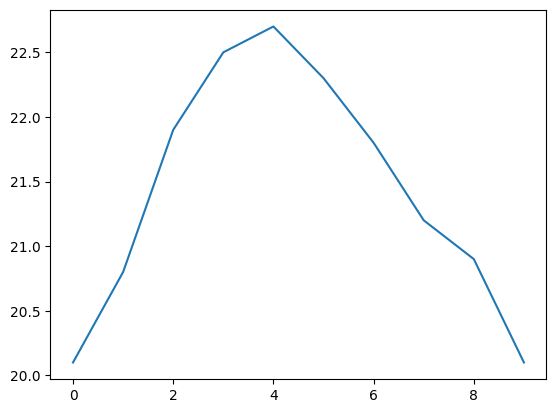

In [8]:
import matplotlib.pyplot as plt

plt.plot(C)
plt.show()

# Memory Consumption

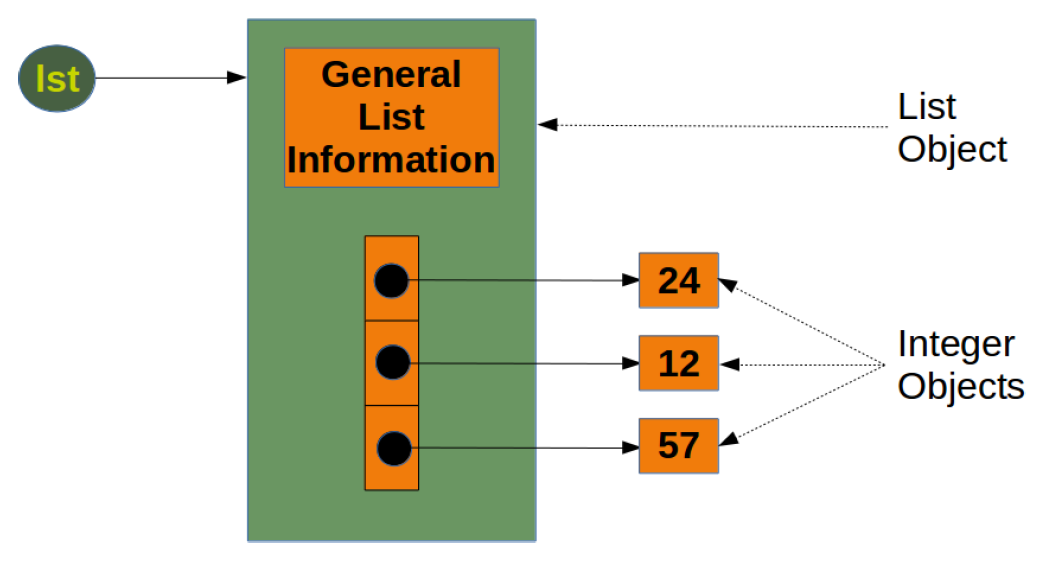

### Python `sys.getsizeof`

In [9]:
from sys import getsizeof as size

In [10]:
# Have a simple list
lst = [24, 12, 57]

In [11]:
# Memory consumpltion of THE LIST OBJECT ITSELF, WITHOUT ELEMENTS
size_of_list_object = size(lst)
print(size_of_list_object)

88


In [12]:
# Get the size of the elements
def size_of_object(l):
    return size(l)
def size_of_elements(l):
    sof = 0
    for element in l:
        sof += size(element)
    return sof
def total_size(l):
    return size_of_object(l) + size_of_elements(l)

print(size_of_elements(lst))


84


In [13]:
# Total memory size of the list
print(total_size(lst))

172


In [14]:
# Add an element to the list
lst = [24, 12, 57, 42]
print(size_of_object(lst))
print(size_of_elements(lst))
print(total_size(lst))

88
112
200


In [15]:
# Size increase per element:
lst = [24]
b1 = size_of_object(lst)
s1 = size_of_elements(lst)
lst = [24, 12]
b2 = size_of_object(lst)
s2 = size_of_elements(lst)
lst = [24, 12, 57]
b3 = size_of_object(lst)
s3 = size_of_elements(lst)
lst = [24, 12, 57, 42]
b4 = size_of_object(lst)
s4 = size_of_elements(lst)
lst = [24, 12, 57, 42, 5123]
b5 = size_of_object(lst)
s5 = size_of_elements(lst)
print(b2-b1, b3-b2, b4-b3, b5-b4)
print(s2-s1, s3-s2, s4-s3, s5-s4)

8 16 0 16
28 28 28 28


### Learning:

- every new element adds 8 bytes to the size of the object, but it's done with some buffering (add 2 places, the 0)
- every new integer occupies 28 bytes
- the total size of THE OBJECT ITSELF = __64 + 8 * the number of list elements__

# NumPy memory consumption

Numpy automatically chooses a fixed integer size. In our example "int64".
We can determine the size of the integers, when we define an array. Needless to say, this changes the memory
requirement:


In [16]:
a = np.array([24, 12, 57], np.int8)
print(size(a) - 96)
a = np.array([24, 12, 57], np.int16)
print(size(a) - 96)
a = np.array([24, 12, 57], np.int32)
print(size(a) - 96)
a = np.array([24, 12, 57], np.int64)
print(size(a) - 96)

19
22
28
40


# Speed comparison

Adding 2 10 million long vectors:

Differences depend on the size, for this, NumPy was __37 times faster__ than standard Python.

In [17]:
import time
size_of_vec = 10000000

def pure_python_version():
    t1 = time.time()
    X = range(size_of_vec)
    Y = range(size_of_vec)
    Z = [X[i] + Y[i] for i in range(len(X)) ]
    return time.time() - t1

def numpy_version():
    t1 = time.time()
    X = np.arange(size_of_vec)
    Y = np.arange(size_of_vec)
    Z = X + Y
    return time.time() - t1

In [18]:
t1 = pure_python_version()
t2 = numpy_version()
print(t1, t2)
print("Numpy is in this example " + str(t1/t2) + " times faster!")

1.3560121059417725 0.048157453536987305
Numpy is in this example 28.157886398629614 times faster!


# `timeit()` module

`from timeit import Timer`

Then to create the object itself, it needs 2 parameters as String:
- what to execute
- what to do before, e.g. how to get the executable code.

After that, the Timer.timeit(n) executes the executable n times and gives back the execution time.



In [19]:
import numpy as np
from timeit import Timer

size_of_vec = 1000
X_list = range(size_of_vec)
Y_list = range(size_of_vec)

X = np.arange(size_of_vec)
Y = np.arange(size_of_vec)

# These 2 functions are now defined in __main__:
def pure_python_version():
    Z = [X_list[i] + Y_list[i] for i in range(len(X_list)) ]
def numpy_version():
    Z = X + Y

# Create the 2 Timer object
# - the function is one of the above
# - the initialization imports the function from __main__
timer_obj1 = Timer("pure_python_version()", "from __main__ import pure_python_version")
timer_obj2 = Timer("numpy_version()", "from __main__ import numpy_version")

# Let the timer execute them 10 times and measure:
for i in range(3):
    t1 = timer_obj1.timeit(10)
    t2 = timer_obj2.timeit(10)
    print("time for pure Python version: ", t1)
    print("time for Numpy version: ", t2)
    print(f"Numpy was {t1 / t2:7.2f} times faster!")

time for pure Python version:  0.0015223000000332831
time for Numpy version:  5.649999991419463e-05
Numpy was   26.94 times faster!
time for pure Python version:  0.0012990000000172586
time for Numpy version:  3.370000001723383e-05
Numpy was   38.55 times faster!
time for pure Python version:  0.0012646999999788022
time for Numpy version:  0.00018320000003768655
Numpy was    6.90 times faster!


With the `repeat()` method the run can be executed r x n times:

In [20]:
print(timer_obj1.repeat(repeat=3, number=10))
print(timer_obj2.repeat(repeat=3, number=10))

[0.0012282000000141124, 0.001586399999951027, 0.0012580000000070868]
[0.000137999999992644, 1.0299999985363684e-05, 1.0299999985363684e-05]


# __Arrays__

## `arange()`

`ndarray a = np.arange(start, stop, step, [dtype=...])`
- start = the start value (float or integer)
- stop = do not further than this
- step = in what steps


In [21]:
x = np.arange(0.5, 10.4, 0.8)
print(x)

[ 0.5  1.3  2.1  2.9  3.7  4.5  5.3  6.1  6.9  7.7  8.5  9.3 10.1]


Careful with giving dtype...

In [22]:
x = np.arange(0.5, 10.4, 0.8, int)
print(x)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12]


`linspace()`

To give, into how many intervals to divide the range.

`linspace(start, stop, num=50, endpoint=True, retstep=False)`

- endpoint: take the stop into it or not?

In the followint example:
- in 1st, the endpoint is counted in, so it divided to __6__ slices
- in 2nd, the endpoint was not included, so divided to __7__.

In [23]:
print(np.linspace(1, 10, 7))
print(np.linspace(1, 10, 7, endpoint=False))

[ 1.   2.5  4.   5.5  7.   8.5 10. ]
[1.         2.28571429 3.57142857 4.85714286 6.14285714 7.42857143
 8.71428571]


If the `reststep = True`, it returs the step values too:

In [25]:
samples, spacing = np.linspace(1, 10, 20, endpoint=True, retstep=True)
print(spacing)

0.47368421052631576


# __Array Dimensions__

Scalar = 0 dimension

In [26]:
x = np.array(42)
print("x: ", x)
print("The type of x: ", type(x))
print("The dimension of x:", np.ndim(x))

x:  42
The type of x:  <class 'numpy.ndarray'>
The dimension of x: 0


Vectors = 1 dimension

In [27]:
F = np.array([1, 1, 2, 3, 5, 8, 13, 21])
V = np.array([3.4, 6.9, 99.8, 12.8])
print("F: ", F)
print("V: ", V)
print("Type of F: ", F.dtype)
print("Type of V: ", V.dtype)
print("Dimension of F: ", np.ndim(F))
print("Dimension of V: ", np.ndim(V))

F:  [ 1  1  2  3  5  8 13 21]
V:  [ 3.4  6.9 99.8 12.8]
Type of F:  int64
Type of V:  float64
Dimension of F:  1
Dimension of V:  1


Multidimensional

In [28]:
A = np.array(
    [ 
        [3.4, 8.7, 9.9],
        [1.1, -7.8, -0.7],
        [4.1, 12.3, 4.8]
    ]
)
print(A)
print(A.ndim)

[[ 3.4  8.7  9.9]
 [ 1.1 -7.8 -0.7]
 [ 4.1 12.3  4.8]]
2


In [29]:
B = np.array(
    [ 
        [
            [111, 112], 
            [121, 122]
        ],
        [
            [211, 212], 
            [221, 222]
        ],
        [
            [311, 312], 
            [321, 322]
        ]
    ]
)
print(B)
print(B.ndim)

[[[111 112]
  [121 122]]

 [[211 212]
  [221 222]]

 [[311 312]
  [321 322]]]
3


# Shape

This indicates the __processing order__:
When loop, the last dimension is the fastest to change, the first the slowest.

In [30]:
print(np.shape(B))
print(B.shape)

(3, 2, 2)
(3, 2, 2)


# Reshape

In [31]:
B.shape = (3,4) # DEPRECATED!!
print(B)


[[111 112 121 122]
 [211 212 221 222]
 [311 312 321 322]]


In [32]:
B.shape = (12)
print(B)

[111 112 121 122 211 212 221 222 311 312 321 322]


In [33]:
B.shape = (4,3)
print(B)

[[111 112 121]
 [122 211 212]
 [221 222 311]
 [312 321 322]]


In [35]:
B.shape = (1,1,1,1,1,1,1,12)
print(B)
print(B.shape)

[[[[[[[[111 112 121 122 211 212 221 222 311 312 321 322]]]]]]]]
(1, 1, 1, 1, 1, 1, 1, 12)


## Correct way: `a = b.reshape()`

In [36]:
A = B.reshape((1,1,1,1,1,1,1,12))
print(A)

[[[[[[[[111 112 121 122 211 212 221 222 311 312 321 322]]]]]]]]


# __Indexing and slicing__

In [37]:
F = np.array([1, 1, 2, 3, 5, 8, 13, 21])
# print the first element of F
print(F[0])
# print the last element of F
print(F[-1])

1
21


watch the indexing, 1st the row, then the column:

In [39]:
A = np.array([ 
    [3.4, 8.7, 9.9],
    [1.1, -7.8, -0.7],
    [4.1, 12.3, 4.8]])

print(A[1][0])

1.1


## __THIS IS UNEFFICIENT__

because first creates a separate object of the row, then selects the 1st element of it.

Do it in 1 step:

In [40]:
print(A[1, 0])

1.1


## Slices

In [41]:
S = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
print(S[2:5])
print(S[:4])
print(S[6:])
print(S[:])

[2 3 4]
[0 1 2 3]
[6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [42]:
A = np.array([
[11, 12, 13, 14, 15],
[21, 22, 23, 24, 25],
[31, 32, 33, 34, 35],
[41, 42, 43, 44, 45],
[51, 52, 53, 54, 55]])

print(A[:3, 2:])

[[13 14 15]
 [23 24 25]
 [33 34 35]]


In [43]:
print(A[3:, :])

[[41 42 43 44 45]
 [51 52 53 54 55]]


In [44]:
print(A[:, 4:])

[[15]
 [25]
 [35]
 [45]
 [55]]


## Using steps

(first we create a 1D vector, and change it to a 2D matrix with `reshape()`)

In [45]:
X = np.arange(28).reshape(4, 7)
print(X)

[[ 0  1  2  3  4  5  6]
 [ 7  8  9 10 11 12 13]
 [14 15 16 17 18 19 20]
 [21 22 23 24 25 26 27]]


Now select every 2nd row, and from them every 3rd column:

In [47]:
print(X[::2, ::3])

[[ 0  3  6]
 [14 17 20]]


## If in the selection we use less dimensions, all the remaining is supposed to be `:`

In [48]:
A = np.array(
[ 
    [ 
        [45, 12, 4], [45, 13, 5], [46, 12, 6] 
    ],
    [ 
        [46, 14, 4], [45, 14, 5], [46, 11, 5] 
    ],
    [ 
        [47, 13, 2], [48, 15, 5], [52, 15, 1] 
    ] 
])

A.shape

(3, 3, 3)

In [49]:
A[1:3, 0:2]

array([[[46, 14,  4],
        [45, 14,  5]],

       [[47, 13,  2],
        [48, 15,  5]]])

# Slicing DOES NOT CREATE A COPY of the object, only a VIEW on the same memory territory.

-> Modifying a slice modifies the original.

In [53]:
A = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
S = A[2:6]
S[0] = 22
S[1] = 23
print(A)
print(S)

[ 0  1 22 23  4  5  6  7  8  9]
[22 23  4  5]


with standard Python we get copy, the original is unchanged:

In [54]:
lst = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
lst2 = lst[2:6]
lst2[0] = 22
lst2[1] = 23
print(lst)
print(lst2)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[22, 23, 4, 5]


# `np.may_share_memory()`

This function
- calculates the memory boundaries of 2 objects
- returns true if they overlap
- it is __not 100% perfect__, can return a false True... 

In [55]:
np.may_share_memory(A, S)

True

In [56]:
np.may_share_memory(A, B)

False

Page 31